In [2]:
#from __future__ import division # uncomment this if using Python 2.7
import numpy as np
from scipy import signal,  ndimage, misc
import matplotlib.pyplot as plt
from matplotlib import cm
from skimage import data, color, img_as_float, img_as_ubyte, filters, feature

%matplotlib inline
from IPython.display import HTML, display

# Hybrid images

With this homework we will check your level of familiarity with spatial filters and image handling. 

To reach our goal we will implement a super simplified version of the so called <i> hybrid images </i>. An hybrid image merges together two different images at different resolution. The effect is that, depending on the distance at which you are looking at the image, you may perceive either one or the other 

Here you see an example (but to appreciate it you need to move away from the screen!)

<img src="hybrid.jpg" width="300">

In essence an hybrid image may be computed as a sum of two filtered images: the first one filtered with a smoothing filter (eg a Gaussian) the second one with an edge sharpener (eg the LoG operator)

<img src="hybrid_pipeline.png" width="440">

See these links for more information on the subject
<a href="https://www.researchgate.net/publication/220184425_Hybrid_images"> [Paper]   </a>
<a href="https://en.wikipedia.org/wiki/Hybrid_image">[Wikipedia]</a>



## To start

We start playing with two predefined images from skimage. 
They don't make too much sense together, but they are easy to play with! 

<Figure size 640x480 with 0 Axes>

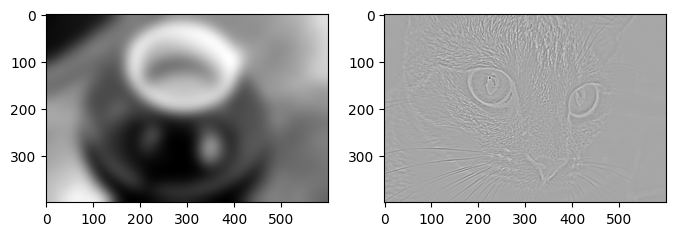

In [5]:
# GAUSSIAN filter on image 1
# LOG ON IMAGE 2

# load two images and turn them gray
img1 = data.coffee() 
img1_gray=img_as_float(color.rgb2gray(img1))
img2 = data.chelsea()
img2_gray=img_as_float(color.rgb2gray(img2))

# NOTICE: the two images must have the same size
# adjust the size of the secont one to match it to the first 
from skimage import transform 
img2_gray = transform.resize(img2_gray, img1_gray.shape)

# Smooth the first image with a Gaussian filter 
#it will become the low resolution one, the one that you see from a distance
sigma=15 # TRY OUT DIFFERENT PARAMETERS!
img1_smooth = ndimage.gaussian_filter(img1_gray, sigma=sigma)

# Smooth the first image with an edge enhancer. the ideal choice would be the LoG filter (second derivatives)
# but you may also try with a first derivatives filter such as Sobel or Roberts (skimage.filters)

#img2_smooth=filters.laplace(img2_gray,k)
#img2_smooth=filters.roberts(img2_gray)
img2_smooth = ndimage.gaussian_laplace(img2_gray, sigma=1)

# Visualize the results independently
plt.gray()
plt.figure(figsize=(8,6))
plt.subplot(121)
plt.imshow(img1_smooth, cmap=cm.gist_gray)
 
plt.subplot(122)
plt.imshow(img2_smooth, cmap=cm.gist_gray)



Text(0.5, 1.0, 'hybrid')

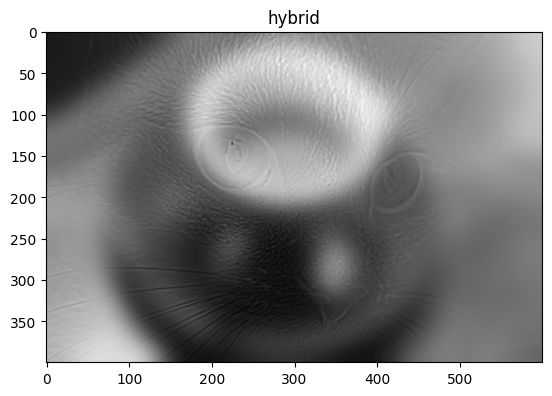

In [6]:
#It's not time to combine the images 
#(a simple sum should do, but you may want to weigh one component more than the other)

img3= img1_smooth + img2_smooth
plt.imshow(img3, cmap=cm.gist_gray)
plt.title("hybrid")

## What now

<ul>
    <li> Find two other images of your choice an try and replicate the same procedure (an elephant and a cheetah?)
    </li>
    <li> Notice there may be an extra problem: the main objects in the two images should be covering similar areas of the image otherwise the trick won't work! </li>
    <li> How about trying with color images? </li>
</ul>
 